<a href="https://colab.research.google.com/github/KarlaRL666/DataAnalysisPython/blob/main/EntrenamientoYPrueba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Importar librerías
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [ ]:
# 2. Crear dataset
data = {
    "humedad_suelo": [20, 65, 15, 70, 30, 80, 25, 55, 10, 60, 35, 75, 18, 68, 22],
    "nivel_agua": [120, 800, 90, 750, 300, 900, 200, 650, 50, 700, 250, 850, 100, 780, 180],
    "temperatura": [35, 24, 38, 23, 32, 22, 34, 26, 40, 25, 33, 21, 37, 24, 36],
    "consumo_electrico": [160, 90, 180, 85, 140, 80, 155, 95, 200, 88, 145, 82, 175, 87, 165],
    "presion_bomba": [20, 45, 18, 48, 28, 50, 22, 42, 15, 46, 30, 49, 19, 47, 21],
    "riesgo_falla": [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
  }

df = pd.DataFrame(data)

In [ ]:
# 3. Visualizar datos
print("Dataset inicial:")
print(df)

Dataset inicial:
    humedad_suelo  nivel_agua  temperatura  consumo_electrico  presion_bomba  \
0              20         120           35                160             20   
1              65         800           24                 90             45   
2              15          90           38                180             18   
3              70         750           23                 85             48   
4              30         300           32                140             28   
5              80         900           22                 80             50   
6              25         200           34                155             22   
7              55         650           26                 95             42   
8              10          50           40                200             15   
9              60         700           25                 88             46   
10             35         250           33                145             30   
11             75      

In [ ]:
# 4. Separar variables independientes y etiqueta
X = df[[
     "humedad_suelo",
     "nivel_agua",
     "temperatura",
     "consumo_electrico",
     "presion_bomba"
]]

y = df["riesgo_falla"]

In [ ]:
# 5. Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

In [ ]:
# 6. Crear y entrenar modelo supervisado
modelo = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

modelo.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
# 7. Realizar predicciones
y_pred = modelo.predict(X_test)

In [ ]:
# 8. Evaluar el modelo
precision = accuracy_score(y_test, y_pred)

print("\nPrecisión del modelo:", precision)
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Precisión del modelo: 1.0

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



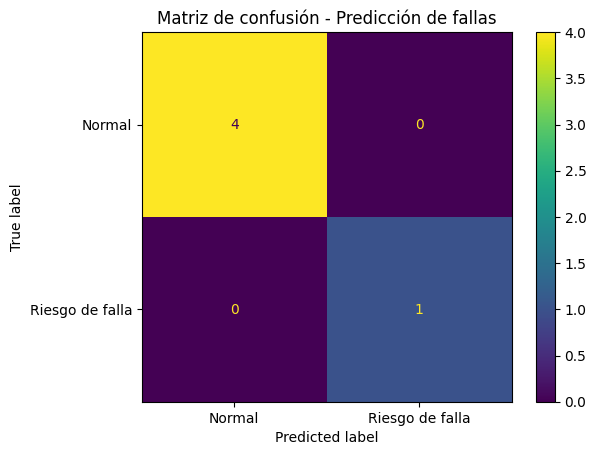

In [ ]:
# 9. Matriz de confusión
matriz = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Normal", "Riesgo de falla"]
)

disp.plot()
plt.title("Matriz de confusión - Predicción de fallas")
plt.show()

In [ ]:
# 10. Predicción con nuevos datos
# Caso nuevo:
# humedad_suelo = 16%
# nivel_agua = 110 litros
# temperatura = 39°C
# consumo_electrico = 185 watts
# presion_bomba = 17 PSI

nuevo_dato = [[16, 110, 39, 185, 17]]

prediccion = modelo.predict(nuevo_dato)

if prediccion[0] == 1:
  print("\nResultado: El sistema tiene riesgo de falla.")
else:
  print("\nResultado: El sistema funciona de manera normal.")


Resultado: El sistema tiene riesgo de falla.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
